In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [199]:
cars = pd.read_csv('cars.csv')
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [200]:
# extract car company

cars['car_company'] = cars['CarName'].apply(lambda x: x.split(' ')[0])
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [201]:
# wrong spellings

corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}
cars['car_company'] = cars['car_company'].replace(corrections)
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [202]:
# doornumber and cylindernumber have words instead of numbers

def wordToNum(word):
    dict = {
        'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'eight': 8, 'twelve': 12
    }
    return dict.get(word, np.nan)

cars['doornumber'] = cars['doornumber'].apply(wordToNum)
cars['cylindernumber'] = cars['cylindernumber'].apply(wordToNum)

cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [203]:
# try to convert every column to numerical

for col in cars.columns:
    if cars[col].dtype == 'object':
        try:
            cars[col] = pd.to_numeric(cars[col])
        except ValueError:
            continue

In [204]:
# fill missing values with median

for col in cars.select_dtypes(include=np.number).columns:
    cars[col].fillna(cars[col].median(), inplace=True)

/var/folders/zt/dnbp074s07d6c21ds_p19rdr0000gn/T/ipykernel_15200/2629467873.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars[col].fillna(cars[col].median(), inplace=True)


In [205]:
# car model name isn't necessary for regression as we already have car company

cars = cars.drop(['car_ID', 'CarName'], axis=1)
cars.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,3,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [206]:
# info after cleaning

cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   fueltype          205 non-null    object 
 2   aspiration        205 non-null    object 
 3   doornumber        205 non-null    int64  
 4   carbody           205 non-null    object 
 5   drivewheel        205 non-null    object 
 6   enginelocation    205 non-null    object 
 7   wheelbase         205 non-null    float64
 8   carlength         205 non-null    float64
 9   carwidth          205 non-null    float64
 10  carheight         205 non-null    float64
 11  curbweight        205 non-null    int64  
 12  enginetype        205 non-null    object 
 13  cylindernumber    205 non-null    int64  
 14  enginesize        205 non-null    int64  
 15  fuelsystem        205 non-null    object 
 16  boreratio         205 non-null    float64
 1

In [207]:
# one-hot encoding

features_with_dummies = pd.get_dummies(cars, columns=cars.select_dtypes(include=['object']).columns, drop_first=True)

In [219]:
# manual train-test split

shuffled_df = features_with_dummies.sample(frac=1, random_state=69)

# split point at 0.7 (70%) for training
train_size = int(0.7 * len(shuffled_df))
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

y_train_raw = train_df.pop('price').values
X_train_df = train_df

y_test_raw = test_df.pop('price').values
X_test_df = test_df

In [209]:
# feature scaling

mean_X = X_train_df.mean()
std_X = X_train_df.std()
X_train_scaled = (X_train_df - mean_X) / std_X
X_test_scaled = (X_test_df - mean_X) / std_X

mean_y = y_train_raw.mean()
std_y = y_train_raw.std()
y_train = (y_train_raw - mean_y) / std_y
y_test = (y_test_raw - mean_y) / std_y

In [261]:
# gradient descent

X_train = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled.values]
X_test = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled.values]

nan_cols = np.any(np.isnan(X_train), axis=0)
X_train = X_train[:, ~nan_cols]
X_test = X_test[:, ~nan_cols]

alpha = 0.05
iterations = 5000
m = len(y_train)
gradient_threshold = 1

theta = np.zeros(X_train.shape[1])
prev_cost = float('inf')
costs = []

for i in range(iterations):
    predictions = X_train.dot(theta)
    err = predictions - y_train
    cost = np.mean(err ** 2)
    costs.append(cost)
    
    if abs(prev_cost - cost) < 1e-10:
        print(f"Converged at iteration {i}")
        break
        
    gradient = (1/m) * X_train.T.dot(err)
    
    gradient_norm = np.linalg.norm(gradient)
    if gradient_norm > gradient_threshold:
        gradient = gradient * gradient_threshold / gradient_norm
        
    theta = theta - (alpha * gradient)
    prev_cost = cost

In [262]:
# calculate R-squared

y_pred = X_test.dot(theta)
ss_residuals = np.sum((y_test - y_pred)**2)
ss_total = np.sum((y_test - np.mean(y_test))**2)
r_squared = 1 - (ss_residuals / ss_total)

print(f"R-squared: {r_squared:.4f}")

R-squared: 0.9200


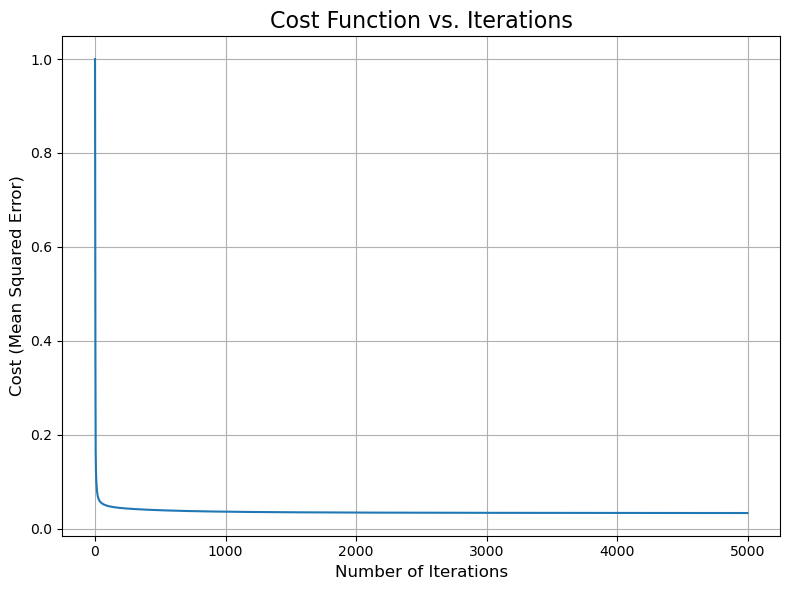

In [263]:
# cost vs iterations plot

plt.figure(figsize=(8, 6))
plt.plot(range(iterations), costs)
plt.title('Cost Function vs. Iterations', fontsize=16)
plt.xlabel('Number of Iterations', fontsize=12)
plt.ylabel('Cost (Mean Squared Error)', fontsize=12)
plt.grid(True)
plt.tight_layout()

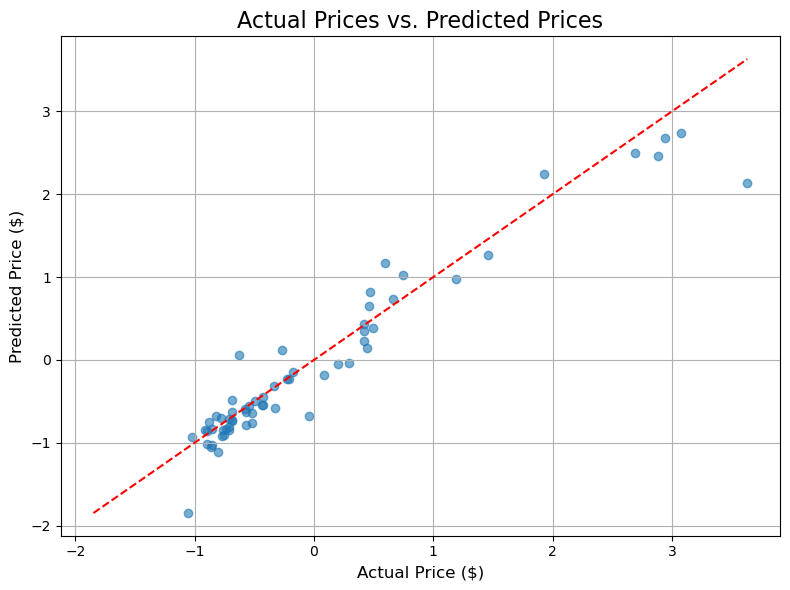

In [264]:
# regression plot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

line_coords = np.linspace(min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), 100)
plt.plot(line_coords, line_coords, color='red', linestyle='--')

plt.title('Actual Prices vs. Predicted Prices', fontsize=16)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.grid(True)
plt.tight_layout()